## Annual Technology Baseline Reporting

### Offshore Wind

In [25]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

from time import perf_counter
from pathlib import Path

from waves import Project
from waves.utilities import load_yaml
from waves.utilities import check_ref_sites

from waves.utilities.atb_tools import breakdown_plots

import matplotlib.pyplot as plt


### Check config files based on reference site table.

In [16]:
year = 2023
library_path = Path(f"../library/atb_base_{year}/")

config_path = library_path / "project/config"
ref_site_df = check_ref_sites(config_path, "reference sites.xlsx", verbose=False)

ref_site_df

Site1_atb_2023_install.yaml
Update:  export_system_design {'cables': 'XLPE_1000mm_220kV'}
Update2:  export_system_design cables XLPE_1000mm_220kV
<class 'dict'> <class 'str'> <class 'str'> <class 'str'>
{'cables': 'XLPE_1000mm_220kV', 'percent_added_length': 0.0}
Update:  site {'depth': 34, 'mean_windspeed': 9, 'distance': 116, 'distance_to_landfall': 50}
Update2:  site depth 34
<class 'dict'> <class 'str'> <class 'str'> <class 'int'>
{'depth': 34, 'distance': 116, 'distance_to_landfall': 50, 'mean_windspeed': 9}
Update2:  site mean_windspeed 9
<class 'dict'> <class 'str'> <class 'str'> <class 'int'>
{'depth': 34, 'distance': 116, 'distance_to_landfall': 50, 'mean_windspeed': 9}
Update2:  site distance 116
<class 'dict'> <class 'str'> <class 'str'> <class 'int'>
{'depth': 34, 'distance': 116, 'distance_to_landfall': 50, 'mean_windspeed': 9}
Update2:  site distance_to_landfall 50
<class 'dict'> <class 'str'> <class 'str'> <class 'int'>
{'depth': 34, 'distance': 116, 'distance_to_landfal

,Site,Description,Coordinates (internal only),"Plant capacity, MW","Turbine rating, MW",Fixed/floating,Foundation type,Export system,"Spacing between turbines, km","Water depth, m","Export cable length, km","Mean wind speed (at 137 m), m/s","Distance to port, km"
0,1,COWER,NaN,600,12,Fixed,Monopile,HVAC,7D,34,50,9,116
1,2,"High-wind, shallow, close to shore",NaN,600,12,Fixed,Monopile,HVAC,7D,30,40,11,75
2,3,"High-wind, deep, close to shore",NaN,1000,12,Fixed,Monopile,HVDC,7D,55,40,11,57
3,4,"High-wind, shallow, far from shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,160,11,175
4,5,"High-wind, deep, far from shore",NaN,1000,12,Fixed,Monopile,HVDC,7D,55,160,11,175
5,6,"Moderate-wind, shallow, close to shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,40,9,75
6,7,"Moderate-wind, deep, close to shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,55,40,9,75
7,8,"Moderate-wind, shallow, far from shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,160,9,175
8,9,"Moderate-wind, deep, far from shore",NaN,1000,12,Fixed,Monopile,HVDC,7D,55,160,9,175
9,10,"Low-wind, shallow, close to shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,40,7,75


#### Initialize the projects from dictionary configuration files. 

In [17]:
site_names = []
project_list = []

for _, row in ref_site_df.iterrows():

    base = f"Site{row['Site']}_atb_{year}.yaml"
    site_names.append(base.split('_')[0])

    config = load_yaml(config_path, base)

    config.update({"library_path" : library_path,
                  # "orbit_config" : Path(atb_path / "orbit_config" / f"Site{row['Site']}_atb_{year}_install.yaml").resolve(),
                  # "wombat_config" : Path(atb_path / "wombat_config" / f"Site{row['Site']}_atb_{year}_operations.yaml").resolve(),
                  # "floris_config" : Path(atb_path / "floris_config" / f"Site{row['Site']}_atb_{year}_floris_jensen.yaml").resolve(),
                    }
    )

    start = perf_counter()

    project = Project.from_dict(config)
    project_list.append(project)

    end = perf_counter()

    print(f"{base} loading time: {(end-start):.2f} seconds")


'H' is deprecated and will be removed in a future version, please use 'h' instead.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}


Missing data in columns ['bury_speed']; all values will be calculated.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
Site1_atb_2023.yaml loading time: 5.32 seconds


'H' is deprecated and will be removed in a future version, please use 'h' instead.

...

Missing data in columns ['bury_speed']; all values will be calculated.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
Site21_atb_2023.yaml loading time: 5.56 seconds


'H' is deprecated and will be removed in a future version, please use 'h' instead.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
Site22_atb_2023.yaml loading time: 5.39 seconds


Missing data in columns ['bury_speed']; all values will be calculated.

#### Run Project

In [18]:

id = len(project_list)
for i,p in enumerate(project_list[:id]):

    start1 = perf_counter()
    p.run(
        full_wind_rose=False,  # use the WOMBAT date range
    )
    p.wombat.env.cleanup_log_files()  # Delete logging data from the WOMBAT simulations

    end1 = perf_counter()

    print(f"{site_names[i]} run time: {end1 - start1:,.2f} seconds")

Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/quayside_assembly_tow/moored.py:94
support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.
['towing_vessl_groups]['station_keeping_vessels'] will be deprecated and replaced with ['towing_vessl_groups]['ahts_vessels'].

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

Site1 run time: 94.30 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/quayside_assembly_tow/moored.py:94
support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.
['towing_vessl_groups]['station_keeping_vessels'] will be deprecated and replaced with ['towing_vessl_groups]['ahts_vessels'].

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

Site2 run time: 69.63 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/quayside_assembly_tow/moored.py:94
support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.
['towing_vessl_groups]['station_keeping_vessels'] will be deprecated and replaced with ['towing_vessl_groups]['ahts_vessels'].

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

...

Site20 run time: 99.27 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/quayside_assembly_tow/moored.py:94
support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.
['towing_vessl_groups]['station_keeping_vessels'] will be deprecated and replaced with ['towing_vessl_groups]['ahts_vessels'].

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

Site21 run time: 109.63 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/quayside_assembly_tow/moored.py:94
support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.
['towing_vessl_groups]['station_keeping_vessels'] will be deprecated and replaced with ['towing_vessl_groups]['ahts_vessels'].

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

Site22 run time: 144.28 seconds


### Simple Report Generation

In [ ]:
report_df_final = pd.DataFrame()
metrics_configuration = {
    "Project Capacity (MW)": {
        "metric": "capacity",
        "kwargs": {"units": "mw"}
    },
    "CapEx (M$)": {
        "metric": "capex",
        "kwargs": {"million": True,}
    },
    "CapEx per kW ($/kW)": {
        "metric": "capex",
        "kwargs": {"per_capacity": "kw"}
    },
    "Soft CapEx (M$)" :{
        "metric": "soft_capex",
        "kwargs": {"million": True,}
    },
    "Soft CapEx per kW ($/kW)": {
        "metric": "soft_capex",
        "kwargs": {"per_capacity": "kw",}
    },
    "OpEx per kW ($/kW)": {
        "metric": "opex",
        "kwargs": {"per_capacity": "kw",
                   }},
    "AEP (MWh)": {
        "metric": "energy_production",
        "kwargs": {"units": "mw", "aep": True }
    },
    "Net Capacity Factor With All Losses (%)": {
        "metric": "capacity_factor",
        "kwargs": {"which": "net", }
    },
    "LCOE ($/MWh)": {"metric": "lcoe"},
}

for i,p in enumerate(project_list[:id]):

# Generate the reports using WAVES and the above configurations
# NOTE: the results are transposed to view them more easily for the example, otherwise
# each row would be a project, which is helpful for combining the results of many scenarios

    report_df = p.generate_report(metrics_configuration, site_names[i])

    n_years = p.operations_years

    report_df["Annual OpEx per kW ($/kW-year)"] = report_df["OpEx per kW ($/kW)"] / n_years

    report_df.pop('OpEx per kW ($/kW)')
# Combine all reports into one, easy to view dataframe
    report_df_final = report_df_final.join(report_df.T, how="outer",).fillna(0.0)

    report_df_final.index.name = "Metrics"

report_df_final.to_csv("reference_sites_report.csv")

report_df_final

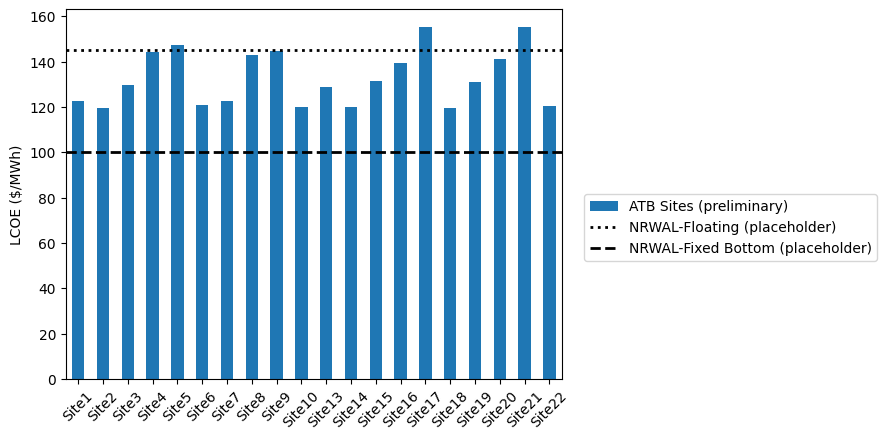

In [138]:
row = "LCOE ($/MWh)"
report_df_final.loc[row].plot(kind='bar', rot=45,label='ATB Sites (preliminary)')
plt.axhline(100, color='black', linestyle='--', linewidth=2, label='NRWAL-Fixed Bottom (placeholder)')
plt.axhline(145, color='black', linestyle=':', linewidth=2, label='NRWAL-Floating (placeholder)')

plt.ylabel(row)
plt.legend(bbox_to_anchor=(1.65, 0.3), loc='lower right', reverse=True)

In [128]:
def stacked_bar_chart(df, transpose=False, lpos=(1.5,0.5)):

    if transpose:
        df = df.T
        xticks = df.index
        ylabel = df.columns.name
    else:
        df = df
        xticks = df.columns
        ylabel = df.index.name

    df.plot(kind='bar', stacked=True)
    plt.xticks(rotation=45)
    plt.ylabel(ylabel)
    #plt.xlabel("ATB Site")

    plt.legend(bbox_to_anchor=lpos, loc='lower right', reverse=True)
    #plt.title(df.index.name)

    #plt.legend()

                                  CapEx per kW
Array System                            222.06
Export System                           241.56
Substructure                           1051.18
Mooring System                           96.65
Offshore Substation                     224.98
Array System Installation               288.43
Export System Installation              105.86
Substructure Installation               122.09
Mooring System Installation              91.68
Offshore Substation Installation          9.49
Turbine                                1500.00
Soft                                    982.24
Project                                 252.08
Total                                  5188.29
                                  CapEx per kW
Array System                            222.06
Export System                           194.21
Substructure                           1051.18
Mooring System                           94.79
Offshore Substation                     223.84
Array System 

,Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site13,Site14,Site15,Site16,Site17,Site18,Site19,Site20,Site21,Site22
CapEx ($/kW),,,,,,,,,,,,,,,,,,,,
Array System,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06,222.06
Array System Installation,288.43,287.27,286.69,289.85,289.85,287.27,287.27,289.85,289.85,287.27,449.32,446.09,446.09,448.77,448.77,446.09,446.09,448.77,448.77,446.09
Export System,241.56,194.21,113.31,762.21,444.51,194.21,194.33,762.21,444.51,194.21,212.98,233.01,236.82,533.63,535.85,233.01,236.82,533.63,535.85,233.01
Export System Installation,105.86,88.08,45.59,255.80,138.17,88.08,88.10,255.80,138.17,88.08,129.26,130.88,131.24,178.10,178.48,130.88,131.24,178.10,178.48,130.88
Mooring System,96.65,94.79,106.41,94.79,106.41,94.79,106.41,94.79,106.41,94.79,459.35,151.37,611.92,151.37,611.92,151.37,611.92,151.37,611.92,151.37
Mooring System Installation,91.68,90.85,92.32,92.62,94.32,90.85,92.76,92.62,94.32,90.85,153.38,111.12,160.65,114.08,190.46,111.12,160.65,114.08,190.46,111.12
Offshore Substation,224.98,223.84,753.22,237.49,753.22,223.84,223.84,237.49,753.22,223.84,223.38,223.84,223.84,753.22,753.22,223.84,223.84,753.22,753.22,223.84
Offshore Substation Installation,9.49,8.60,8.22,10.78,10.79,8.60,8.61,10.78,10.79,8.60,14.79,9.21,10.56,14.03,14.75,9.21,10.56,14.03,14.75,9.21
Project,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08


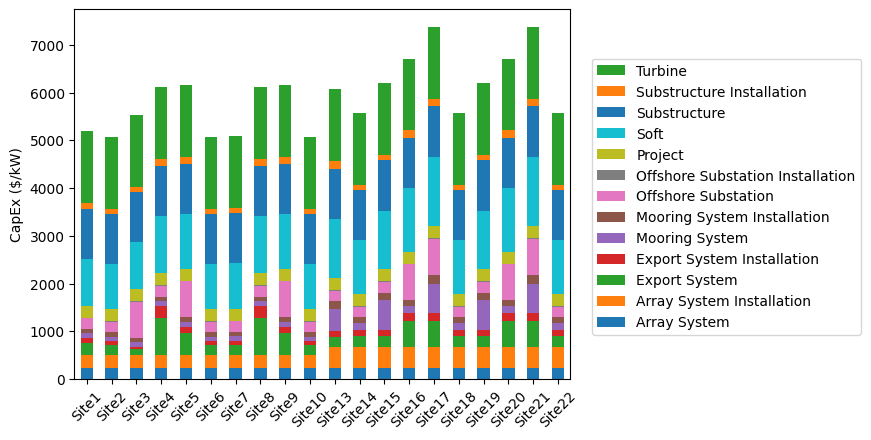

In [136]:
# Capture the CapEx breakdown for each reference site

report_capex_df = pd.DataFrame()

for i,p in enumerate(project_list[:id]):

    _temp_df = p.capex(breakdown=True,per_capacity="kw").drop(columns=["CapEx"])
    print(_temp_df)
    _temp_df.columns = [f"{site_names[i]}"]

    #_temp_df[f"{site_names[i]} CapEx ($kW)"] = _temp_df[f"{site_names[i]} CapEx ($)"] / p.capacity("kw")

    report_capex_df = report_capex_df.join(_temp_df, how="outer").fillna(0.0)

#report_capex_df = report_capex_df / 1e6
report_capex_df.index.name = "CapEx ($/kW)"

report_capex_df.to_csv("reference_sites_capex_report.csv")

stacked_bar_chart(report_capex_df.drop("Total"), transpose=True, lpos=(1.6, 0.1))

report_capex_df


,Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site13,Site14,Site15,Site16,Site17,Site18,Site19,Site20,Site21,Site22
Soft CapEx ($/kW),,,,,,,,,,,,,,,,,,,,
Commissioning,48.37,47.34,52.07,56.56,57.63,47.34,47.50,56.56,57.63,47.34,55.60,51.19,57.12,61.88,68.09,51.19,57.12,61.88,68.09,51.19
Construction Financing,320.60,312.58,342.16,380.26,383.63,312.58,313.67,380.26,383.63,312.58,377.71,345.62,386.29,419.13,462.50,345.62,386.29,419.13,462.50,345.62
Construction Insurance,85.80,83.98,92.38,100.32,102.24,83.98,84.26,100.32,102.24,83.98,98.63,90.81,101.33,109.77,120.79,90.81,101.33,109.77,120.79,90.81
Decommissioning,108.07,101.23,92.74,139.66,119.38,101.23,101.57,139.66,119.38,101.23,159.94,143.16,152.13,160.53,174.09,143.16,152.13,160.53,174.09,143.16
Installation Contingency,213.05,199.56,182.83,275.33,235.34,199.56,200.24,275.33,235.34,199.56,315.30,282.23,299.91,316.47,343.20,282.23,299.91,316.47,343.20,282.23
Procurement Contingency,206.34,203.44,229.90,236.89,248.94,203.44,204.12,236.89,248.94,203.44,225.46,208.93,235.63,256.65,283.26,208.93,235.63,256.65,283.26,208.93
Total,982.24,948.13,992.09,1189.03,1147.17,948.13,951.36,1189.03,1147.17,948.13,1232.65,1121.95,1232.41,1324.44,1451.93,1121.95,1232.41,1324.44,1451.93,1121.95


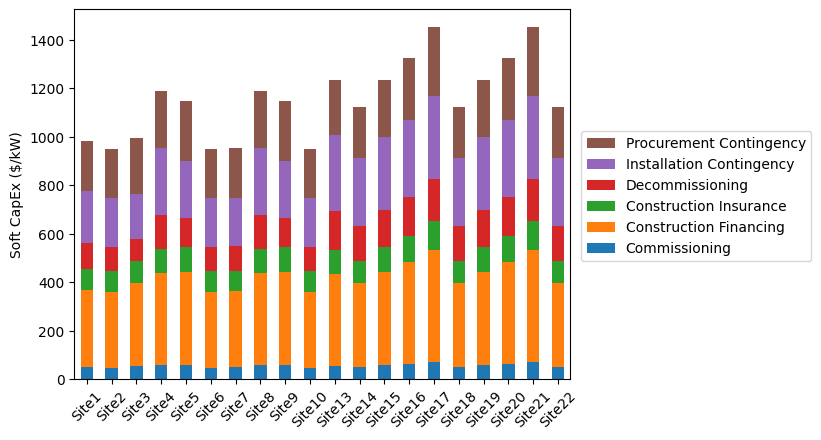

In [137]:
# Capture the Soft CapEx breakdown for each reference site

report_soft_capex_df = pd.DataFrame()

for i,p in enumerate(project_list[:id]):

    _temp_df = p.soft_capex(breakdown=True,per_capacity="kw").drop(columns=["Soft CapEx"])
    _temp_df.columns = [f"{site_names[i]}"]

    #_temp_df[f"{site_names[i]} Soft CapEx ($kW)"] = _temp_df[f"{site_names[i]} Soft CapEx ($)"] / p.capacity("kw")

    report_soft_capex_df = report_soft_capex_df.join(_temp_df, how="outer").fillna(0.0)

#report_soft_capex_df = report_soft_capex_df / 1e6
report_soft_capex_df.index.name = "Soft CapEx ($/kW)"

report_soft_capex_df.to_csv("reference_sites_soft_capex_report.csv")

stacked_bar_chart(report_soft_capex_df.drop("Total"), transpose=True,lpos=(1.5, 0.3))

report_soft_capex_df


,Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site13,Site14,Site15,Site16,Site17,Site18,Site19,Site20,Site21,Site22
Losses (%),,,,,,,,,,,,,,,,,,,,
Availability Losses,6.82,6.57,6.94,7.37,7.89,7.06,7.44,7.12,7.11,6.76,8.43,8.89,8.52,7.91,8.74,8.76,8.43,8.48,9.00,9.00
Electrical Losses,3.52,3.35,3.37,3.98,4.00,3.35,3.37,3.98,4.00,3.35,3.71,3.43,3.94,4.06,4.57,3.43,3.94,4.06,4.57,3.43
Environmental Losses,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59
Technical Losses,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.20,1.20,1.20,1.20,1.20,1.20,1.20,1.20,1.20,1.20
Total Losses,19.28,18.92,19.26,20.15,20.60,19.35,19.69,19.93,19.94,19.09,19.69,19.86,19.96,19.53,20.68,19.75,19.89,20.03,20.91,19.95
Wake Losses,7.84,7.84,7.84,7.84,7.84,7.84,7.84,7.84,7.84,7.84,6.33,6.33,6.33,6.33,6.33,6.33,6.33,6.33,6.33,6.33


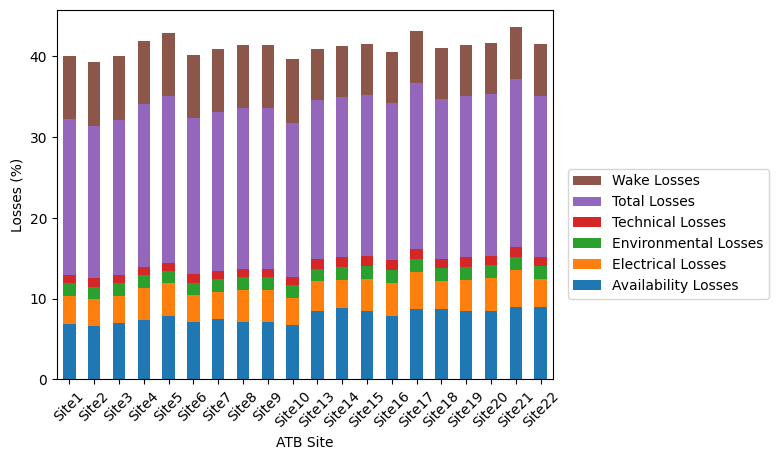

In [103]:
# Capture the Losses breakdown for each reference site

losses_report_df = pd.DataFrame()

for i,p in enumerate(project_list[:id]):

    _temp_df = p.loss_ratio(breakdown=True)
    _temp_df.columns =[f"{site_names[i]}"]

    losses_report_df = losses_report_df.join(_temp_df, how='outer').fillna(0.0)
    losses_report_df.index.name = "Losses (%)"

stacked_bar_chart(losses_report_df, transpose=True,lpos=(1.45, 0.2))

losses_report_df.to_csv("reference_sites_losses_report.csv")

losses_report_df


In [71]:
print(losses_report_df.index.name)
print(losses_report_df.columns)

Losses (%)
Index(['Site1', 'Site2', 'Site3', 'Site4', 'Site5', 'Site6', 'Site7', 'Site8',
       'Site9', 'Site10', 'Site13', 'Site14', 'Site15', 'Site16', 'Site17',
       'Site18', 'Site19', 'Site20', 'Site21', 'Site22'],
      dtype='object')
